In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

plt.style.use('default')



**Dataset link:** https://rb.gy/gsmddu

**Add a label to every axis and add a proper title for the charts (For every subplot, it is applicable). Also add proper labels if there are multiple representations.** Then, you can customize it as your wish.

### **Problem-1:** Make a subplots which have 2 plots.

- For the first chart, draw a scatter plot "*Monitored Cap.(MW)*" vs "*Total Cap. Under Maintenance (MW)*" of top 5 most frequent power stations. Then draw the lines which indicate the average values of these two columns. Change the colors according to the names of the Power Stations.
- For the second chart, draw a scatter plot "*Monitored Cap. (MW)*" vs "*Actual(MU)*" of the top 5 most frequent power stations. Also draw the lines which indicates the average values of these two columns. Change the colors according to the names of the Power Stations.


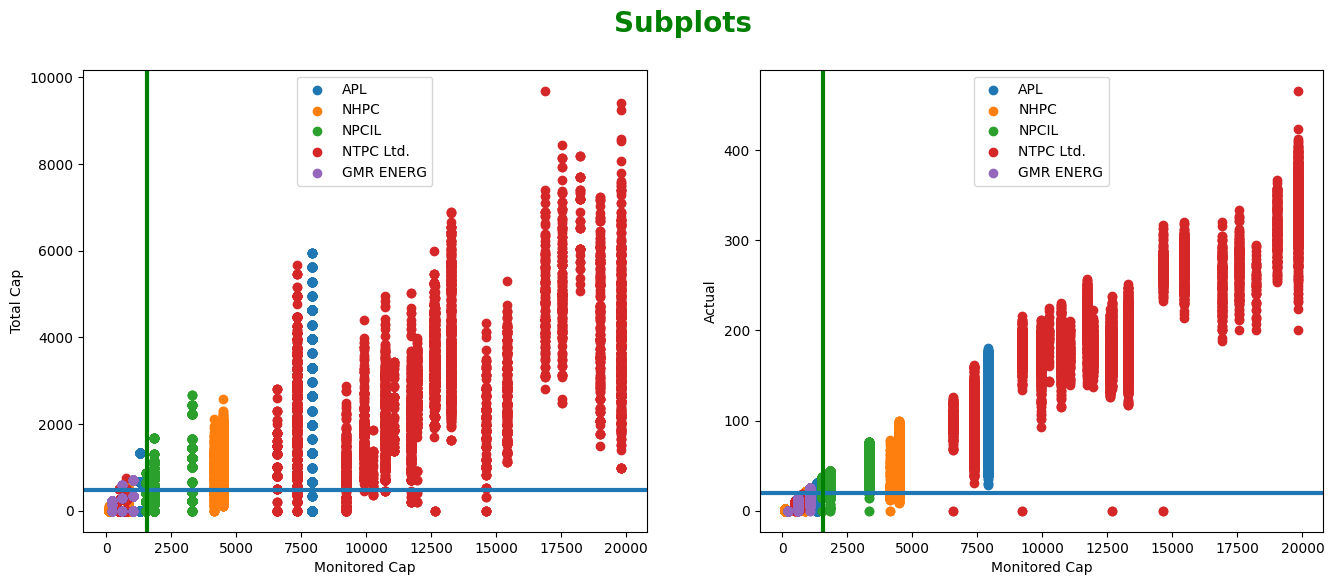

In [167]:

# code here

df = pd.read_csv('data/24_data/PowerGeneration - PowerGeneration.csv')
top_5 = df[df["Power Station"].isin(df["Power Station"].value_counts().head().index)]
top_5["Power"]= top_5["Power Station"].map(dict(top_5["Power Station"].value_counts().reset_index().reset_index().set_index("Power Station").drop(columns=["count"]).squeeze()))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for i in top_5["Power Station"].unique():
    fil = top_5[top_5["Power Station"]==i]
    ax[0].scatter(fil["Monitored Cap.(MW)"], fil["Total Cap. Under Maintenace (MW)"], label=i)
ax[0].legend()
ax[0].set_xlabel("Monitored Cap")
ax[0].set_ylabel("Total Cap")
ax[0].axhline(df["Total Cap. Under Maintenace (MW)"].mean(), linewidth=3)
ax[0].axvline(df["Monitored Cap.(MW)"].mean(), color="green", linewidth=3)

for i in top_5["Power Station"].unique():
    fil = top_5[top_5["Power Station"]==i]
    ax[1].scatter(fil["Monitored Cap.(MW)"], fil["Actual(MU)"], label=i)
ax[1].legend()
ax[1].set_xlabel("Monitored Cap")
ax[1].set_ylabel("Actual")
ax[1].axhline(df["Actual(MU)"].mean(), linewidth=3)
ax[1].axvline(df["Monitored Cap.(MW)"].mean(), color="green", linewidth=3)

plt.suptitle("Subplots",fontweight='bold', color='green', fontsize=20)
plt.show()

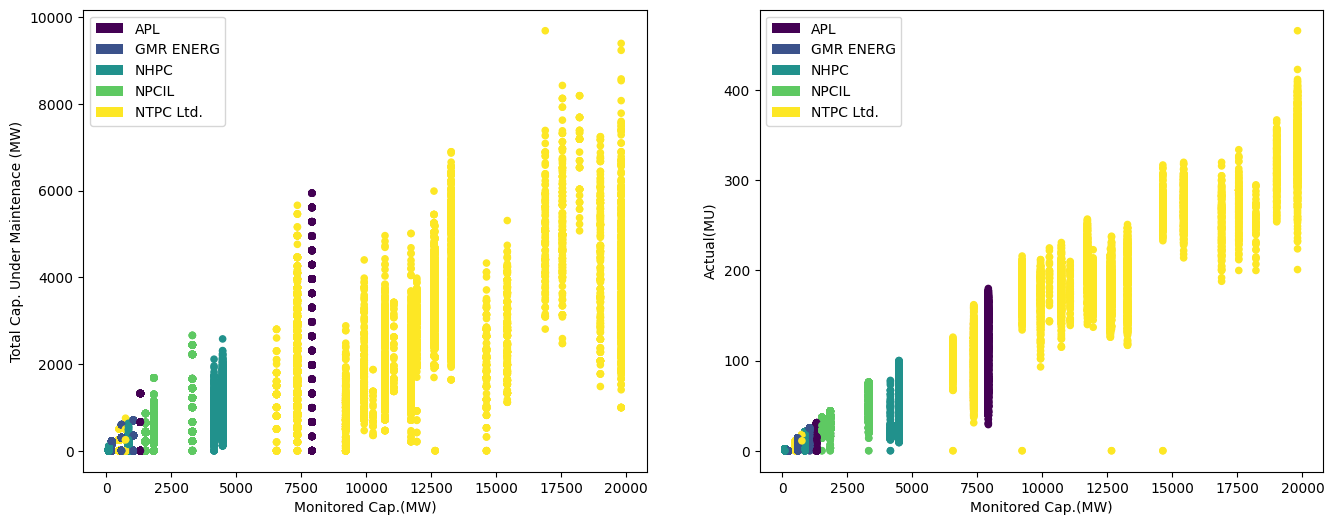

In [38]:
# method 2
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
top_5.plot(kind='scatter', x="Monitored Cap.(MW)", y="Total Cap. Under Maintenace (MW)", c="Power Station", ax=ax[0])
top_5.plot(kind='scatter', x="Monitored Cap.(MW)", y="Actual(MU)", c="Power Station", ax=ax[1])
plt.show()




Data Set Link - https://docs.google.com/spreadsheets/d/17tUL2yC7MGvo7txuuhLtAI-b6_C4jc0t7FLFxqRm-uI/edit?usp=share_link


**Description of Dataset:**

* Date: It gives the date of which stocks details are given.
* Symbol: Name of stock
* Open: It gives the opening price of stock on that date.
* High: It gives the highest price to which the stock ascened on that day.
* Low: It gives the highest price to which the stock plummeted on that day.
* Close: It gives the closing price of stock on that date.
* Volume: It gives the amount of stock traded on that date.
* VWAP: The volume-weighted average price (VWAP) is a statistic used by traders to determine what the average price is based on both price and volume.
* Turnover:

### `Problem-2` Use Pandas plot functions

* Line plot of closing value of top 5 Stocks in Year 2020.
* Take top 5 stocks based on total turnover in Year 2020

In [141]:
# code here

df = pd.read_csv('data/24_data/nifty-50 - nifty-50.csv')
df["Date"] = pd.to_datetime(df["Date"])
fil = df[df["Date"].dt.year==2020]
final = fil[fil["Symbol"].isin(fil.groupby('Symbol')["Turnover"].sum().sort_values(ascending=False).head(5).index)].sort_values(by="Date")
# method_1

final.drop_duplicates(inplace=True)


<Axes: xlabel='Date'>

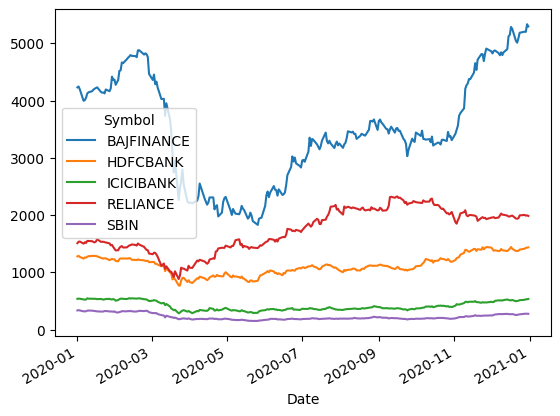

In [144]:
final.pivot(index='Date', columns='Symbol', values='Close').plot(kind='line')

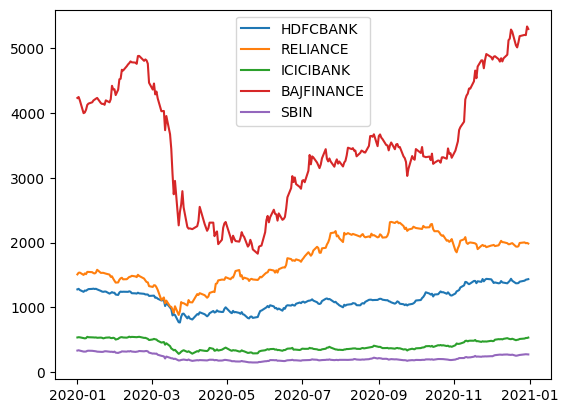

In [146]:
# method_2

for i in final["Symbol"].unique():
    f = final[final["Symbol"]==i]
    plt.plot(f["Date"], f["Close"], label=i)
plt.legend()
plt.show()

### `Problem-3` Scatter plot Close price vs Volume for TOP-5 Stocks in year 2021
* Color on Symbol Column

<Axes: xlabel='Close', ylabel='Volume'>

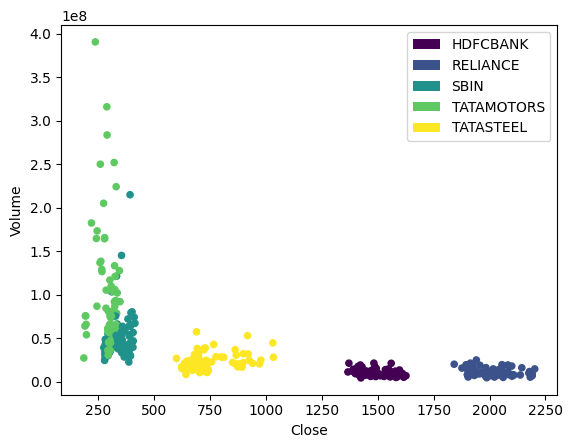

In [156]:
# code here

fil = df[df["Date"].dt.year==2021]
final = fil[fil["Symbol"].isin(fil.groupby('Symbol')["Turnover"].sum().sort_values(ascending=False).head(5).index)].sort_values(by="Date")

final = final.drop_duplicates()
final.plot(kind="scatter", x="Close", y="Volume", c="Symbol")

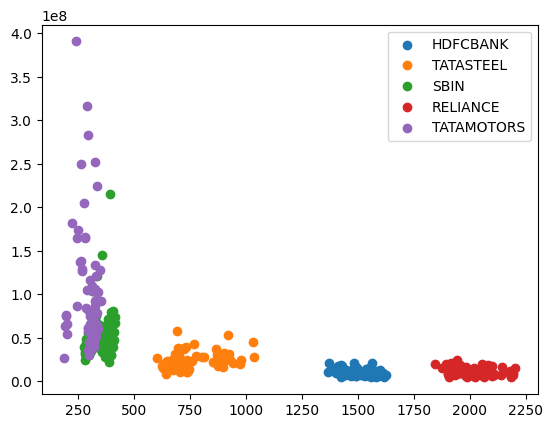

In [169]:

# method_2

for i in final["Symbol"].unique():
    a = final[final["Symbol"]==i]
    plt.scatter(a["Close"], a["Volume"], label=i)
plt.legend()
plt.show()